# 신용카드 채무불이행 고객 예측 -

https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

In [1]:
!pip install xlrd --break-system-packages
# =========================================
# 0) 공통 설정
# =========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay
)

RANDOM_STATE = 42
TARGET_COL = "default"


In [14]:
import pandas as pd
import urllib.request
import os

os.makedirs('./data', exist_ok=True)

# UCI 원본
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
from pathlib import Path

def find_repo_file(*parts):
    start = Path.cwd().resolve()
    for base in (start, *start.parents):
        candidate = base.joinpath(*parts)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(parts)

XLS_PATH = find_repo_file('05_machine_learning', '03_ml_data', 'tabular_datasets', '../03_ml_data/tabular_datasets/UCI_Credit_Card.xls')
CSV_PATH = find_repo_file('05_machine_learning', '03_ml_data', 'tabular_datasets', '../03_ml_data/tabular_datasets/UCI_Credit_Card.csv')
urllib.request.urlretrieve(url, str(XLS_PATH))

# xls 읽기
df = pd.read_excel(XLS_PATH, header=1)
df.to_csv(CSV_PATH, index=False)
print(df.shape)

# df = pd.read_csv(CSV_PATH)
card_df = df.drop('ID', axis=1)
card_df.head()

(30000, 25)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
# 컬럼명 정리 + 타깃 컬럼 자동 탐지/변환
card_df.columns = (
    card_df.columns
    .astype(str)
    .str.strip()
    .str.replace("\n", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
)

# 후보 찾기
target_candidates = [c for c in card_df.columns if "default" in c.lower()]
print("target 후보:", target_candidates)
print("전체 컬럼:", list(card_df.columns))

if "default" not in card_df.columns:
    if "default payment next month" in card_df.columns:
        card_df = card_df.rename(columns={"default payment next month": "default"})
    elif len(target_candidates) == 1:
        card_df = card_df.rename(columns={target_candidates[0]: "default"})
    else:
        raise ValueError(f"타깃 컬럼을 자동 식별하지 못했습니다. 후보: {target_candidates}")

# 최종 확인
TARGET_COL = "default"
y = card_df[TARGET_COL]
X = card_df.drop(columns=[TARGET_COL])

print("완료: target =", TARGET_COL)
print("X shape:", X.shape, "y shape:", y.shape)

target 후보: ['default payment next month']
전체 컬럼: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']
완료: target = default
X shape: (30000, 23) y shape: (30000,)


데이터 크기: (30000, 24)

타깃 비율


default
0    0.7788
1    0.2212
Name: ratio, dtype: float64


결측치 상위


LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
dtype: int64

,outlier_ratio
PAY_2,0.147000
PAY_3,0.140300
PAY_4,0.116933
PAY_0,0.104333
PAY_6,0.102633
PAY_AMT4,0.099800
PAY_5,0.098933
PAY_AMT6,0.098600
PAY_AMT5,0.098167
PAY_AMT1,0.091500


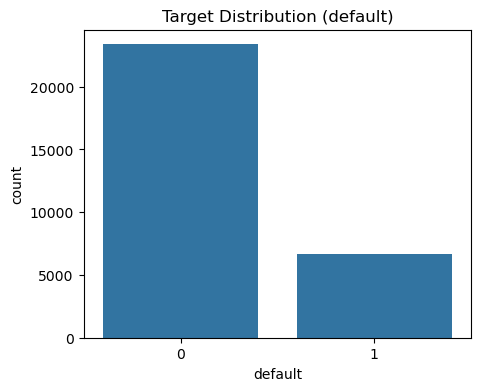

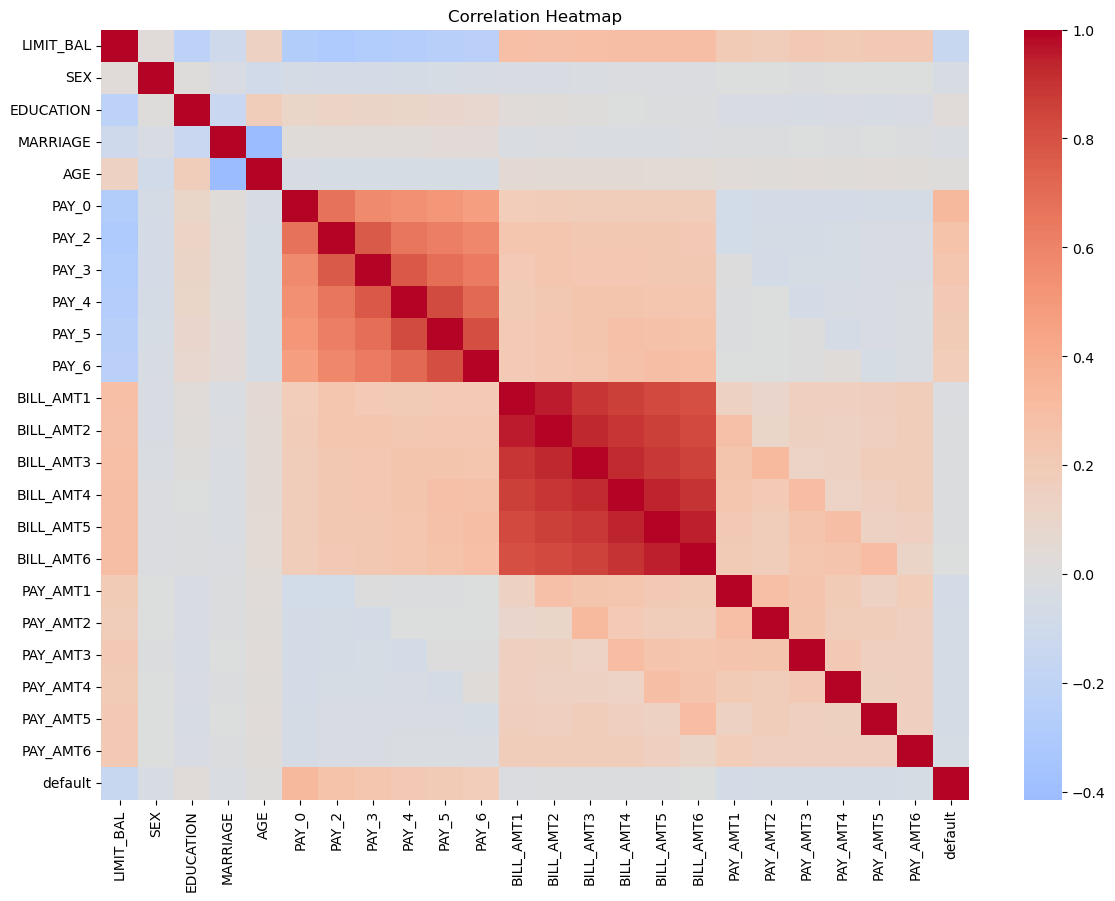

In [6]:
# =========================================
# 1) EDA
# =========================================
# Target 정의
y = card_df[TARGET_COL]
X = card_df.drop(columns=[TARGET_COL])

print("데이터 크기:", card_df.shape)
print("\n타깃 비율")
display(y.value_counts(normalize=True).rename("ratio"))

# 결측치 확인
print("\n결측치 상위")
display(card_df.isna().sum().sort_values(ascending=False).head(20))

# 이상치(수치형 IQR 기준 비율) 간단 점검
num_cols = X.select_dtypes(include=["number"]).columns
outlier_ratio = {}
for c in num_cols:
    q1, q3 = X[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lb, ub = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_ratio[c] = ((X[c] < lb) | (X[c] > ub)).mean()
outlier_ratio = pd.Series(outlier_ratio).sort_values(ascending=False)
display(outlier_ratio.head(10).to_frame("outlier_ratio"))

# 주요 분포 시각화
plt.figure(figsize=(5, 4))
sns.countplot(x=y)
plt.title("Target Distribution (default)")
plt.show()

# 상관관계
corr_df = card_df.select_dtypes(include=["number"]).corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(corr_df, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [7]:
# =========================================
# 2) 데이터 전처리
# =========================================
# 범주형 / 수치형 분리
cat_cols = X.select_dtypes(include=["object", "category"]).columns
num_cols = X.select_dtypes(include=["number"]).columns

print("수치형:", len(num_cols), "개")
print("범주형:", len(cat_cols), "개")

# 불필요 컬럼 제거 예시 (필요 시 사용)
# drop_cols = ["ID"]  # 이미 제거했으면 빈 리스트 유지
drop_cols = []
X = X.drop(columns=drop_cols, errors="ignore")

# 전처리 파이프라인
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])


수치형: 23 개
범주형: 0 개


In [8]:
# =========================================
# 3) Train/Test Split (80:20, stratify)
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(X_train.shape, X_test.shape)
print("Train class ratio:", y_train.mean().round(4), " Test class ratio:", y_test.mean().round(4))

(24000, 23) (6000, 23)
Train class ratio: 0.2212  Test class ratio: 0.2212


In [9]:
# =========================================
# 4) 모델 학습 (LogReg / RF / XGB)
# =========================================
models = {
    "logreg": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "rf": RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "xgb": XGBClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE
    )
}

fitted_pipes = {}
for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    fitted_pipes[name] = pipe
    print(f"{name} 학습 완료")

logreg 학습 완료
rf 학습 완료
xgb 학습 완료


,model,accuracy,precision,recall,f1,roc_auc
0,logreg,0.679667,0.367247,0.620196,0.461323,0.708115
2,xgb,0.817833,0.660714,0.362472,0.468127,0.778303
1,rf,0.814000,0.645920,0.351922,0.455610,0.758735


선택 모델: logreg

[Classification Report]
              precision    recall  f1-score   support

           0     0.8659    0.6966    0.7721      4673
           1     0.3672    0.6202    0.4613      1327

    accuracy                         0.6797      6000
   macro avg     0.6166    0.6584    0.6167      6000
weighted avg     0.7556    0.6797    0.7033      6000



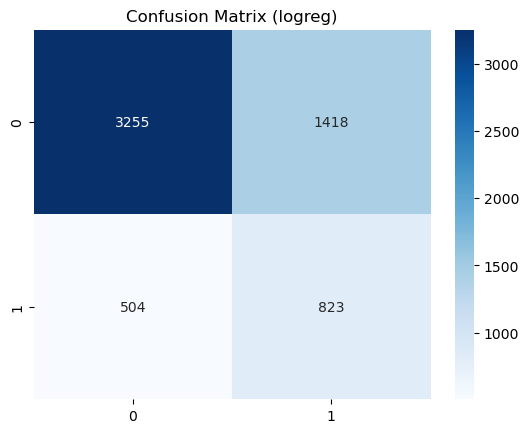

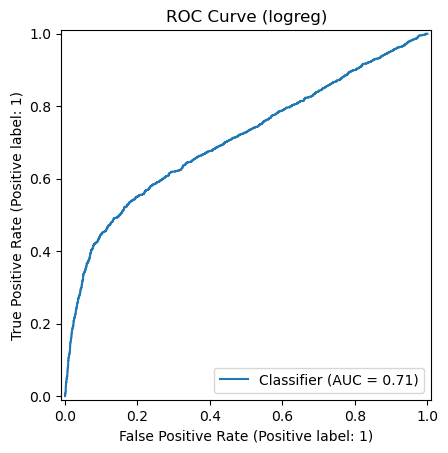

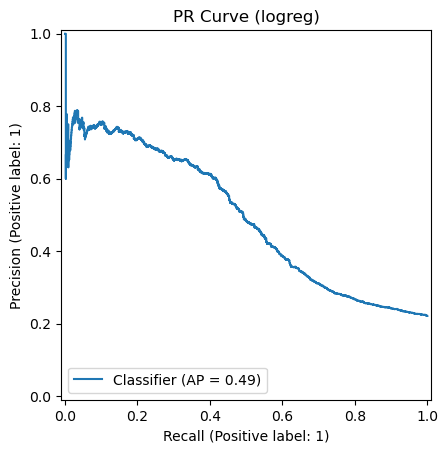

In [10]:
# =========================================
# 5) 모델 평가
# Accuracy / Precision / Recall / F1 / ROC-AUC
# =========================================
def evaluate_model(name, pipe, X_test, y_test, threshold=0.5):
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba)
    }
    return metrics, proba, pred

results = []
proba_dict = {}

for name, pipe in fitted_pipes.items():
    m, proba, pred = evaluate_model(name, pipe, X_test, y_test, threshold=0.5)
    results.append(m)
    proba_dict[name] = proba

result_df = pd.DataFrame(results).sort_values(["recall", "roc_auc", "f1"], ascending=False)
display(result_df)

best_model_name = result_df.iloc[0]["model"]
best_pipe = fitted_pipes[best_model_name]
print("선택 모델:", best_model_name)

print("\n[Classification Report]")
best_pred = (proba_dict[best_model_name] >= 0.5).astype(int)
print(classification_report(y_test, best_pred, digits=4))

cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix ({best_model_name})")
plt.show()

RocCurveDisplay.from_predictions(y_test, proba_dict[best_model_name])
plt.title(f"ROC Curve ({best_model_name})")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, proba_dict[best_model_name])
plt.title(f"PR Curve ({best_model_name})")
plt.show()

In [11]:
# =========================================
# (권장) Recall 중심 임계값 튜닝
# =========================================
thresholds = np.arange(0.1, 0.91, 0.05)
rows = []

proba = proba_dict[best_model_name]
for th in thresholds:
    pred = (proba >= th).astype(int)
    rows.append({
        "threshold": th,
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0)
    })

th_df = pd.DataFrame(rows)
display(th_df.sort_values(["recall", "f1"], ascending=False).head(10))


,threshold,precision,recall,f1
0,0.10,0.222765,0.996986,0.364162
1,0.15,0.224841,0.984928,0.366106
2,0.20,0.231235,0.949510,0.371901
3,0.25,0.237137,0.923888,0.377405
4,0.30,0.244398,0.887717,0.383276
5,0.35,0.257882,0.825923,0.393043
6,0.40,0.276539,0.775433,0.407686
7,0.45,0.304870,0.707611,0.426140
8,0.50,0.367247,0.620196,0.461323
9,0.55,0.470149,0.522231,0.494823


In [12]:
# =========================================
# 6) 피처 중요도 (트리 모델)
# =========================================
if best_model_name in ["rf", "xgb"]:
    model = best_pipe.named_steps["model"]

    # 전처리 후 feature name 추출
    ohe = best_pipe.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
    cat_feature_names = ohe.get_feature_names_out(cat_cols) if len(cat_cols) > 0 else np.array([])
    feature_names = np.concatenate([num_cols, cat_feature_names])

    importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
    display(importances.head(20).to_frame("importance"))

    plt.figure(figsize=(8, 6))
    sns.barplot(x=importances.head(20).values, y=importances.head(20).index)
    plt.title(f"Top 20 Feature Importances ({best_model_name})")
    plt.show()
else:
    print("최적 모델이 트리 기반이 아니어서 feature importance를 생략합니다.")


최적 모델이 트리 기반이 아니어서 feature importance를 생략합니다.


In [13]:
# =========================================
# 7) 하이퍼파라미터 튜닝 (선택)
# RandomizedSearchCV 예시: XGBoost
# =========================================
xgb_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", XGBClassifier(
        eval_metric="logloss",
        random_state=RANDOM_STATE
    ))
])

param_dist = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",   # 필요 시 "recall"로 변경 가능
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

search.fit(X_train, y_train)

print("Best Params:", search.best_params_)
print("Best CV Score(ROC-AUC):", round(search.best_score_, 4))

best_tuned_model = search.best_estimator_
test_proba = best_tuned_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)

print("\n[Tuned Model - Test]")
print("Accuracy :", round(accuracy_score(y_test, test_pred), 4))
print("Precision:", round(precision_score(y_test, test_pred, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, test_pred, zero_division=0), 4))
print("F1       :", round(f1_score(y_test, test_pred, zero_division=0), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, test_proba), 4))


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Params: {'model__subsample': 0.7, 'model__n_estimators': 700, 'model__min_child_weight': 5, 'model__max_depth': 4, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.8}
Best CV Score(ROC-AUC): 0.7846

[Tuned Model - Test]
Accuracy : 0.8187
Precision: 0.6667
Recall   : 0.3602
F1       : 0.4677
ROC-AUC  : 0.7799
